# Yol Risk Analizi — Makine Öğrenimi Projesi
**Veri:** US Accidents (2016–2023) | **Hedef:** Düşük / Orta / Yüksek Risk Sınıflandırması

## HÜCRE 1 — Kütüphaneler

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from lightgbm import LGBMClassifier
from lazypredict.Supervised import LazyClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
import time
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


## HÜCRE 2 — Veri Yükleme

In [6]:
cols = [
    'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Crossing', 'Junction', 'Stop',
    'Traffic_Signal', 'Amenity', 'Bump', 'Give_Way',
    'No_Exit', 'Railway', 'Roundabout', 'Station',
    'Traffic_Calming', 'Sunrise_Sunset'
]

df = pd.read_csv('../data/us_accident.csv', usecols=cols)

print(f'Toplam satır: {len(df):,}')
print(f'Toplam kolon: {df.shape[1]}')
print(f'\nSeverity dağılımı:\n{df["Severity"].value_counts()}')
df.head()

Toplam satır: 7,728,394
Toplam kolon: 24

Severity dağılımı:
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


,Severity,Start_Time,Start_Lat,Start_Lng,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.87,-84.06,36.90,91.00,29.68,10.00,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,Night
1,2,2016-02-08 06:07:59,39.93,-82.83,37.90,100.00,29.65,10.00,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,Night
2,2,2016-02-08 06:49:27,39.06,-84.03,36.00,100.00,29.67,10.00,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,Night
3,3,2016-02-08 07:23:34,39.75,-84.21,35.10,96.00,29.64,9.00,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,Night
4,2,2016-02-08 07:39:07,39.63,-84.19,36.00,89.00,29.65,6.00,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,Day


## HÜCRE 3 — EDA: Eksik Veri Analizi

In [7]:
print('Eksik veri (%%):')
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0].sort_values(ascending=False).round(2))
print(f'\nToplam boyut: {df.shape}')

Eksik veri (%%):
Precipitation(in)   28.51
Wind_Speed(mph)      7.39
Visibility(mi)       2.29
Humidity(%)          2.25
Weather_Condition    2.24
Temperature(F)       2.12
Pressure(in)         1.82
Sunrise_Sunset       0.30
dtype: float64

Toplam boyut: (7728394, 24)


## HÜCRE 4 — EDA: Severity Dağılımı

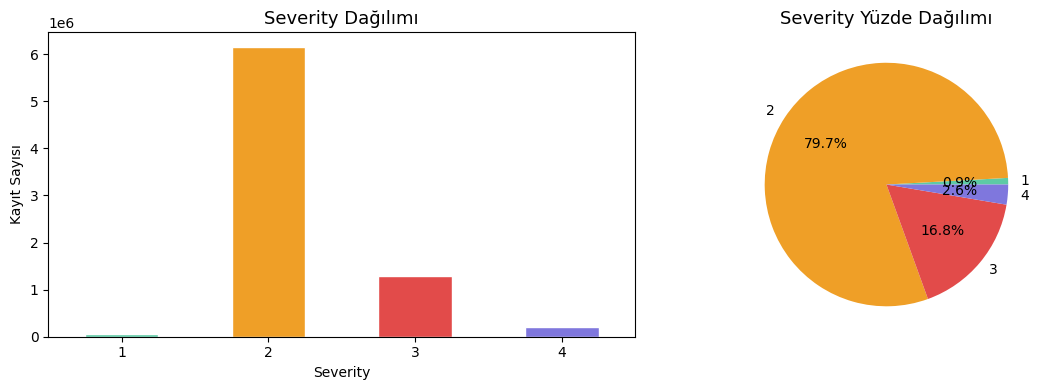

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Severity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD'],
    edgecolor='white'
)
axes[0].set_title('Severity Dağılımı', fontsize=13)
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Kayıt Sayısı')
axes[0].tick_params(axis='x', rotation=0)

df['Severity'].value_counts(normalize=True).sort_index().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD']
)
axes[1].set_title('Severity Yüzde Dağılımı', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## HÜCRE 5 — EDA: Saatlik Kaza Dağılımı

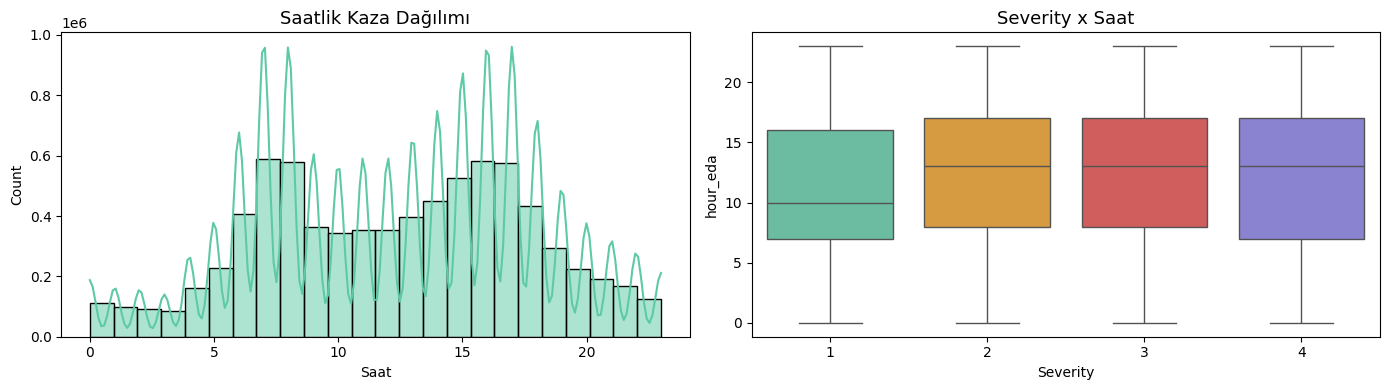

In [9]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['hour_eda'] = df['Start_Time'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['hour_eda'], bins=24, ax=axes[0], color='#5DCAA5', kde=True)
axes[0].set_title('Saatlik Kaza Dağılımı', fontsize=13)
axes[0].set_xlabel('Saat')

sns.boxplot(x='Severity', y='hour_eda', data=df, ax=axes[1],
            palette=['#5DCAA5','#EF9F27','#E24B4A','#7F77DD'])
axes[1].set_title('Severity x Saat', fontsize=13)

plt.tight_layout()
plt.show()

## HÜCRE 6 — EDA: Hava Durumu Dağılımı

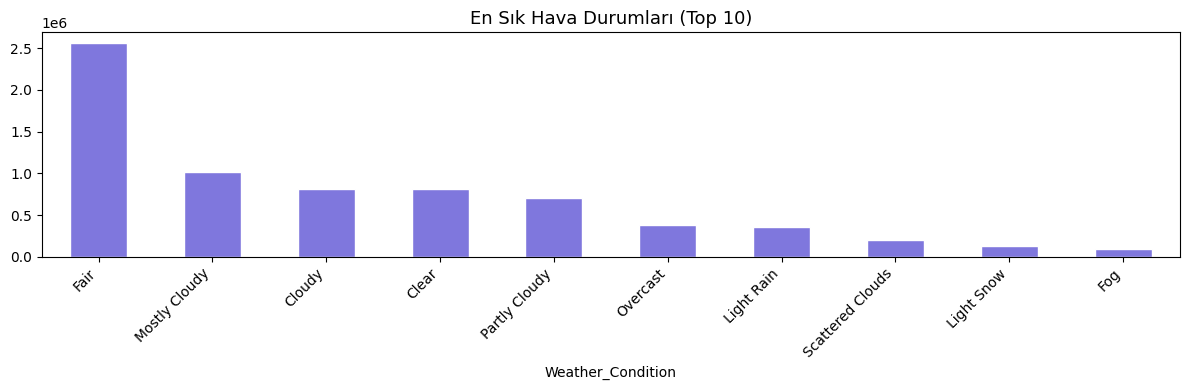

In [10]:
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12, 4))
top_weather.plot(kind='bar', color='#7F77DD', edgecolor='white')
plt.title('En Sık Hava Durumları (Top 10)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## HÜCRE 7 — Etiket Oluşturma (Risk_Level)

In [11]:
# Severity 1+2 → Düşük (0) | Severity 3 → Orta (1) | Severity 4 → Yüksek (2)
df['Risk_Level'] = df['Severity'].map({1: 0, 2: 0, 3: 1, 4: 2})

print('Risk_Level dağılımı:')
print(df['Risk_Level'].value_counts())
print('\nYüzde:')
print(df['Risk_Level'].value_counts(normalize=True).round(3))

Risk_Level dağılımı:
Risk_Level
0    6224347
1    1299337
2     204710
Name: count, dtype: int64

Yüzde:
Risk_Level
0   0.81
1   0.17
2   0.03
Name: proportion, dtype: float64


## HÜCRE 8 — Feature Engineering: Zaman

In [12]:
df['hour']        = df['Start_Time'].dt.hour
df['month']       = df['Start_Time'].dt.month
df['day_of_week'] = df['Start_Time'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

rush_hours = [7, 8, 9, 16, 17, 18]
df['is_rush_hour'] = df['hour'].isin(rush_hours).astype(int)
df['is_night']     = (df['Sunrise_Sunset'] == 'Night').astype(int)

print('Zaman feature\'ları oluşturuldu ✓')
print(df[['hour','month','day_of_week','is_weekend','is_rush_hour','is_night']].head())

Zaman feature'ları oluşturuldu ✓
   hour  month  day_of_week  is_weekend  is_rush_hour  is_night
0     5      2            0           0             0         1
1     6      2            0           0             0         1
2     6      2            0           0             0         1
3     7      2            0           0             1         1
4     7      2            0           0             1         0


## HÜCRE 9 — Feature Engineering: Hava Durumu (Sayısal)

In [13]:
df['Temperature(F)']    = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)']       = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)']      = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)']    = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Wind_Speed(mph)']   = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0.0)

df['low_visibility'] = (df['Visibility(mi)'] < 5).astype(int)
df['extreme_temp']   = ((df['Temperature(F)'] < 32) | (df['Temperature(F)'] > 95)).astype(int)

print('Sayısal hava feature\'ları oluşturuldu ✓')

Sayısal hava feature'ları oluşturuldu ✓


## HÜCRE 10 — Feature Engineering: Hava Durumu (Kategorik)

In [14]:
def group_weather(condition):
    if pd.isna(condition):
        return 'Clear'
    condition = str(condition).lower()
    if any(w in condition for w in ['rain', 'drizzle', 'shower']):
        return 'Rain'
    elif any(w in condition for w in ['snow', 'sleet', 'ice', 'hail', 'wintry']):
        return 'Snow'
    elif any(w in condition for w in ['fog', 'mist', 'smoke', 'haze']):
        return 'Fog'
    elif any(w in condition for w in ['cloud', 'overcast']):
        return 'Cloudy'
    else:
        return 'Clear'

df['Weather_Group'] = df['Weather_Condition'].apply(group_weather)
df['bad_weather']   = df['Weather_Group'].isin(['Rain', 'Snow', 'Fog']).astype(int)

print('Hava grubu dağılımı:')
print(df['Weather_Group'].value_counts())

Hava grubu dağılımı:
Weather_Group
Clear     3648003
Cloudy    3163750
Rain       540467
Fog        202399
Snow       173775
Name: count, dtype: int64


## HÜCRE 11 — Feature Engineering: Yol & POI

In [15]:
poi_columns = ['Crossing', 'Junction', 'Stop', 'Traffic_Signal',
               'Amenity', 'Bump', 'Give_Way', 'No_Exit',
               'Railway', 'Roundabout', 'Station', 'Traffic_Calming']
for col in poi_columns:
    if col in df.columns:
        df[col] = df[col].astype(int)

core_poi = ['Crossing', 'Junction', 'Stop', 'Traffic_Signal']
df['complex_road'] = df[core_poi].sum(axis=1)

print('POI feature\'ları oluşturuldu ✓')

POI feature'ları oluşturuldu ✓


## HÜCRE 12 — Feature Engineering: Interaction Features

In [16]:
df['night_bad_weather'] = df['is_night'] * df['bad_weather']
df['rush_complex_road'] = df['is_rush_hour'] * (df['complex_road'] > 0).astype(int)
df['night_low_vis']     = df['is_night'] * df['low_visibility']

print('Interaction feature\'ları oluşturuldu ✓')
print(f'night_bad_weather=1 olan: {df["night_bad_weather"].sum():,}')

Interaction feature'ları oluşturuldu ✓
night_bad_weather=1 olan: 322,487


## HÜCRE 13 — Gereksiz Kolonları Sil & df_model Oluştur

In [17]:
drop_cols = ['Severity', 'Start_Time', 'Weather_Condition', 'Sunrise_Sunset', 'hour_eda']
df = df.drop(columns=drop_cols, errors='ignore')

# Koordinatları harita için sakla, modelden çıkar
coords   = df[['Start_Lat', 'Start_Lng']].copy()
df_model = df.drop(columns=['Start_Lat', 'Start_Lng'], errors='ignore')

print(f'Final veri boyutu: {df_model.shape}')
print(f'Kolonlar: {list(df_model.columns)}')

Final veri boyutu: (7728394, 33)
Kolonlar: ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Risk_Level', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour', 'is_night', 'low_visibility', 'extreme_temp', 'Weather_Group', 'bad_weather', 'complex_road', 'night_bad_weather', 'rush_complex_road', 'night_low_vis']


## HÜCRE 14 — Encoding (LabelEncoder — Bellek Dostu)

In [18]:
if 'Weather_Group' in df_model.columns:
    le = LabelEncoder()
    df_model['Weather_Group'] = le.fit_transform(
        df_model['Weather_Group'].astype(str)
    )
    print(f'Weather_Group encode edildi ✓ — {dict(enumerate(le.classes_))}')

Weather_Group encode edildi ✓ — {0: 'Clear', 1: 'Cloudy', 2: 'Fog', 3: 'Rain', 4: 'Snow'}


## HÜCRE 15 — Train / Test Split

In [19]:
import gc
gc.collect()  # çöp topla

# df_model'i split ettikten sonra sil
X = df_model[[col for col in df_model.columns if col != 'Risk_Level']]
y = df_model['Risk_Level']

del df_model  # artık gerekmez, sil
del df        # ham veri de sil
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

del X, y  # split sonrası bunlar da gerekmez
gc.collect()

print(f'Train: {X_train.shape[0]:,} satır')
print(f'Test : {X_test.shape[0]:,} satır')

Train: 6,182,715 satır
Test : 1,545,679 satır


## HÜCRE 16 — Sınıf Dengesizliği (class_weight kullanılacak, SMOTE yok)

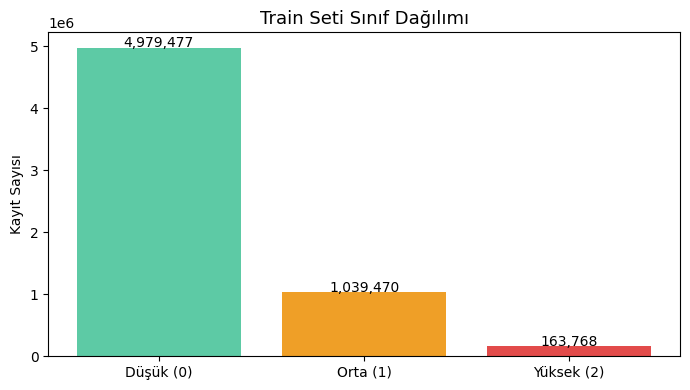


Sınıf dengesizliği → class_weight="balanced" ile yönetilecek ✓


In [20]:
# 7.7M satırda SMOTE RAM patlatır — class_weight='balanced' yeterli
CLASS_WEIGHT = 'balanced'

fig, ax = plt.subplots(figsize=(7, 4))
counts = pd.Series(y_train).value_counts().sort_index()
ax.bar(['Düşük (0)', 'Orta (1)', 'Yüksek (2)'], counts.values,
       color=['#5DCAA5', '#EF9F27', '#E24B4A'])
ax.set_title('Train Seti Sınıf Dağılımı', fontsize=13)
ax.set_ylabel('Kayıt Sayısı')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nSınıf dengesizliği → class_weight="balanced" ile yönetilecek ✓')

## HÜCRE 17 — Baseline: Yardımcı Fonksiyon

In [21]:
results = []

def evaluate_model(name, y_true, y_pred):
    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average='macro')
    f1_weighted= f1_score(y_true, y_pred, average='weighted')

    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1 Macro    : {f1_macro:.4f}   ← asıl metrik')
    print(f'  F1 Weighted : {f1_weighted:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['Düşük','Orta','Yüksek']))
    return {'model': name, 'accuracy': round(acc,4),
            'f1_macro': round(f1_macro,4), 'f1_weighted': round(f1_weighted,4)}

print('Yardımcı fonksiyon hazır ✓')

Yardımcı fonksiyon hazır ✓


## HÜCRE 18 — Baseline 1: Dummy Classifier

In [22]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
results.append(evaluate_model('Dummy (Most Frequent)', y_test, y_pred_dummy))


  Dummy (Most Frequent)
  Accuracy    : 0.8054
  F1 Macro    : 0.2974   ← asıl metrik
  F1 Weighted : 0.7186
              precision    recall  f1-score   support

       Düşük       0.81      1.00      0.89   1244870
        Orta       0.00      0.00      0.00    259867
      Yüksek       0.00      0.00      0.00     40942

    accuracy                           0.81   1545679
   macro avg       0.27      0.33      0.30   1545679
weighted avg       0.65      0.81      0.72   1545679



## HÜCRE 19 — Scaling

In [23]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform sadece train'e
X_test_scaled  = scaler.transform(X_test)        # sadece transform test'e
print('Scaling tamamlandı ✓')

Scaling tamamlandı ✓


## HÜCRE 20 — Baseline 2: Logistic Regression (Dengesiz)

In [24]:
lr_base = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_base.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_base.predict(X_test_scaled)
results.append(evaluate_model('LR — Dengesiz', y_test, y_pred_lr_base))


  LR — Dengesiz
  Accuracy    : 0.8053
  F1 Macro    : 0.2975   ← asıl metrik
  F1 Weighted : 0.7186
              precision    recall  f1-score   support

       Düşük       0.81      1.00      0.89   1244870
        Orta       0.24      0.00      0.00    259867
      Yüksek       0.00      0.00      0.00     40942

    accuracy                           0.81   1545679
   macro avg       0.35      0.33      0.30   1545679
weighted avg       0.69      0.81      0.72   1545679



## HÜCRE 21 — Baseline 3: Logistic Regression (Balanced)

In [25]:
lr_balanced = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight='balanced', n_jobs=-1
)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
results.append(evaluate_model('LR — Balanced', y_test, y_pred_lr_bal))


  LR — Balanced
  Accuracy    : 0.3580
  F1 Macro    : 0.2868   ← asıl metrik
  F1 Weighted : 0.4269
              precision    recall  f1-score   support

       Düşük       0.90      0.31      0.46   1244870
        Orta       0.23      0.58      0.33    259867
      Yüksek       0.04      0.43      0.07     40942

    accuracy                           0.36   1545679
   macro avg       0.39      0.44      0.29   1545679
weighted avg       0.76      0.36      0.43   1545679



## HÜCRE 22 — Karşılaştırma Tablosu & Confusion Matrix


BASELINE KARŞILAŞTIRMA TABLOSU
                       accuracy  f1_macro  f1_weighted
model                                                 
Dummy (Most Frequent)      0.81      0.30         0.72
LR — Dengesiz              0.81      0.30         0.72
LR — Balanced              0.36      0.29         0.43

→ En iyi F1 Macro : LR — Dengesiz (0.2975)
→ Sonraki hedef   : LazyPredict ile bu değeri geçmek


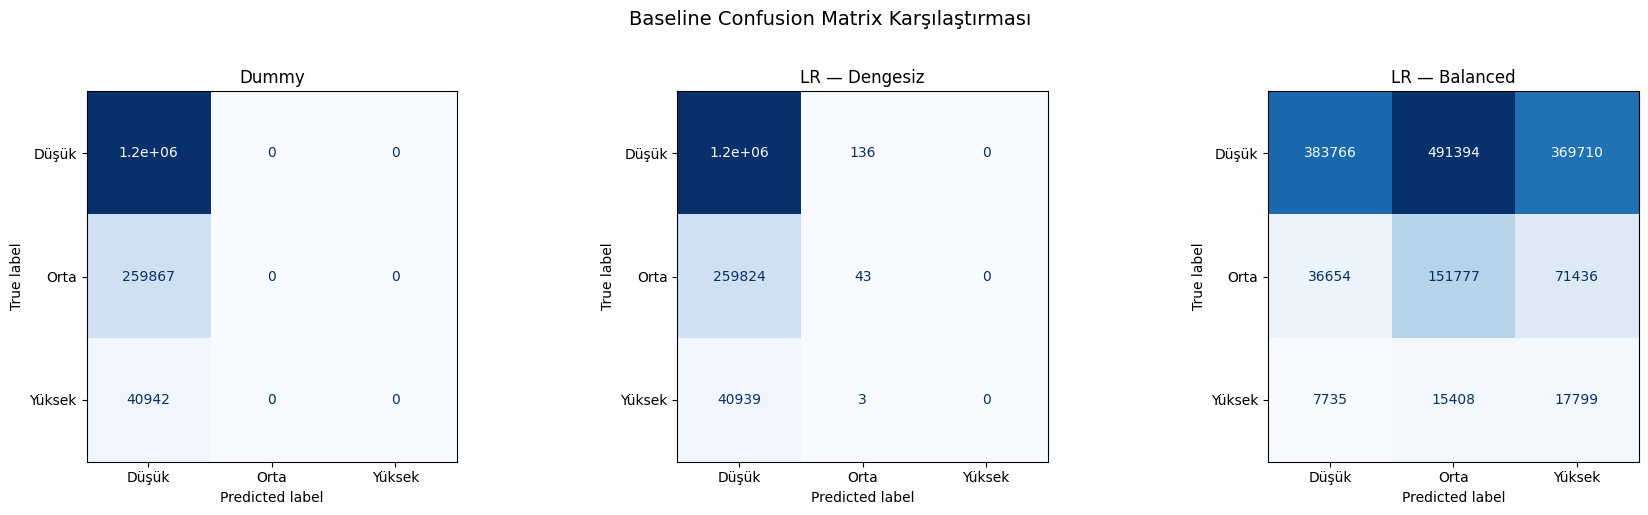

Grafik kaydedildi → baseline_confusion_matrix.png


In [26]:
df_results = pd.DataFrame(results).set_index('model')
print('\nBASELINE KARŞILAŞTIRMA TABLOSU')
print('='*55)
print(df_results.to_string())

best = df_results['f1_macro'].idxmax()
print(f'\n→ En iyi F1 Macro : {best} ({df_results.loc[best,"f1_macro"]:.4f})')
print(f'→ Sonraki hedef   : LazyPredict ile bu değeri geçmek')

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (y_pred, title) in zip(axes, [
    (y_pred_dummy,   'Dummy'),
    (y_pred_lr_base, 'LR — Dengesiz'),
    (y_pred_lr_bal,  'LR — Balanced'),
]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Düşük','Orta','Yüksek'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.suptitle('Baseline Confusion Matrix Karşılaştırması', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi → baseline_confusion_matrix.png')

In [ ]:
X_sample, y_sample = resample(
    X_train_scaled, y_train,
    n_samples=50_000,
    random_state=42,
    stratify=y_train
)
X_test_sample, y_test_sample = resample(
    X_test_scaled, y_test,
    n_samples=10_000,
    random_state=42,
    stratify=y_test
)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(
    X_sample, X_test_sample,
    y_sample, y_test_sample
)
print(models.sort_values('F1 Score', ascending=False).head(10))

In [ ]:
# 1. Modeller Sözlüğü (İstediğin modeli buraya ekleyip çıkarabilirsin)
modeller = {
    "LightGBM_Dengesiz": LGBMClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=2,
        verbose=-1
    ),
    "LightGBM_Balanced": LGBMClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=2,
        class_weight="balanced", # Altın Vuruş
        verbose=-1
    )
}

# 2. Sonuçları tutacağımız liste
tum_sonuclar = []

print("Model eğitimi başlıyor... Lütfen bekleyin, veri boyutu büyük...")

# 3. Eğitim ve Test Döngüsü
for isim, model in modeller.items():
    print(f"\n[{isim}] modeli eğitiliyor...")
    start_time = time.time()
    
    # Model Eğitimi (Scaling edilmiş veri ile)
    model.fit(X_train_scaled, y_train) 
    
    print(f"[{isim}] tahmin yapıyor...")
    # Model Tahmini
    y_pred = model.predict(X_test_scaled) 
    
    # Süre ve Skor Hesaplamaları
    egitim_suresi = time.time() - start_time
    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average="macro")
    f1_wei = f1_score(y_test, y_pred, average="weighted")
    
    # Sonuçları listeye kaydet
    tum_sonuclar.append({
        'Model': isim,
        'Accuracy': round(acc, 4),
        'F1-Macro': round(f1_mac, 4),
        'F1-Weighted': round(f1_wei, 4),
        'Sure (sn)': round(egitim_suresi, 2)
    })
    
    # Her modelin kendi detaylı raporunu ekrana bas
    print(f"\n{'='*55}")
    print(f"  {isim} Sınıflandırma Raporu")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Düşük", "Orta", "Yüksek"]))

# 4. Şampiyonlar Tablosu
df_modeller = pd.DataFrame(tum_sonuclar)
# F1-Macro'ya göre büyükten küçüğe sırala
df_modeller = df_modeller.sort_values(by="F1-Macro", ascending=False).reset_index(drop=True)

print("\n\n🏆 ŞAMPİYONLAR TABLOSU 🏆")
print("="*60)
print(df_modeller.to_string())

# En iyi modeli belirle
en_iyi_model_ismi = df_modeller.iloc[0]['Model']
en_iyi_f1 = df_modeller.iloc[0]['F1-Macro']
print(f"\n💡 En Başarılı Model: {en_iyi_model_ismi} (F1-Macro: {en_iyi_f1:.4f})")

Model eğitimi başlıyor... Lütfen bekleyin, veri boyutu büyük...

[LightGBM_Dengesiz] modeli eğitiliyor...
[LightGBM_Dengesiz] tahmin yapıyor...

  LightGBM_Dengesiz Sınıflandırma Raporu
              precision    recall  f1-score   support

       Düşük       0.81      0.99      0.89   1244870
        Orta       0.55      0.06      0.10    259867
      Yüksek       0.93      0.00      0.00     40942

    accuracy                           0.81   1545679
   macro avg       0.76      0.35      0.33   1545679
weighted avg       0.77      0.81      0.74   1545679


[LightGBM_Balanced] modeli eğitiliyor...
[LightGBM_Balanced] tahmin yapıyor...

  LightGBM_Balanced Sınıflandırma Raporu
              precision    recall  f1-score   support

       Düşük       0.90      0.53      0.67   1244870
        Orta       0.32      0.57      0.41    259867
      Yüksek       0.05      0.45      0.09     40942

    accuracy                           0.53   1545679
   macro avg       0.42      0.51      

In [ ]:
def objective(trial):
    # 1. Optuna'nın deneyeceği parametre aralıkları
    param = {
        'n_estimators': 100, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        
        # Sabit parametreler
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': 2,
        'verbose': -1
    }
    
    # 2. Modeli Kur ve Eğit
    model = LGBMClassifier(**param)
    model.fit(X_train_scaled, y_train)
    
    # 3. Tahmin yap
    y_pred = model.predict(X_test_scaled)
    
    # 4. ALTIN VURUŞ: Yüksek Risk (Sınıf 2) için F2-Skorunu hesapla
    # beta=2 -> Recall, Precision'dan 2 kat daha önemli!
    f2_skorlari = fbeta_score(y_test, y_pred, beta=2, average=None)
    
    # f2_skorlari dizisi sırasıyla [Düşük F2, Orta F2, Yüksek F2] verir.
    # Biz sadece Yüksek Risk (indeks 2) ile ilgileniyoruz.
    hedef_skor = f2_skorlari[2] 
    
    return hedef_skor # Optuna'ya "Sadece bu ağır kazaların F2 skorunu büyüt" diyoruz.

print("F2 Skoru hedeflenerek Optuna optimizasyonu başlıyor...")

# Optuna çalışması oluştur
study = optuna.create_study(direction='maximize')

# Şimdilik 15 deneme yapmasını istiyoruz
study.optimize(objective, n_trials=15)

print("\n"+"="*55)
print("En İyi Yüksek Risk F2-Skoru:", round(study.best_value, 4))
print("En İyi Parametreler:", study.best_params)
print("="*55)